This notebooks allows a user to understand whether a certain counties share of vote was effected by something the leading party did, where a synthetic control is created and the results are compared

In [107]:
import pandas as pd
import plotly.express as px
import numpy as np
from scipy.optimize import nnls
import matplotlib.pyplot as plt

In [108]:
pdf_results = pd.read_csv("data/input/election_results/general_election_results.csv")

In [109]:


def prepare_all_county(pdf: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare vote share data by County and Year.
    Returns party vote percentages and total votes.
    """

    # Pivot votes by County + Year
    pdf_votes = (
        pdf.query("Country == 'England'").query("Geography == 'County'")[["County", "Year", "Party", "Votes"]]
        .pivot_table(
            index=["County", "Year"],
            columns="Party",
            values="Votes",
            aggfunc="sum",
        )
        .reset_index()
    )

    # Identify party columns
    party_cols = pdf_votes.columns.difference(["County", "Year"])

    # Total votes per County-Year
    pdf_votes["Total_Votes"] = pdf_votes[party_cols].sum(axis=1)

    # Convert to percentages
    pdf_votes_pct = pdf_votes.copy()
    pdf_votes_pct[party_cols] = (
        pdf_votes_pct[party_cols]
        .div(pdf_votes_pct["Total_Votes"], axis=0)
        .mul(100)
    )

    return pdf_votes_pct[["County", "Year", "Conservative", "Labour", "Liberal Democrats", 'Green Party', 'Reform UK']].fillna(0)


In [110]:
pdf_all = pdf_results.pipe(prepare_all_county)

In [111]:
START_YEAR = 1945

In [112]:
#HS2 Cancellation + Local Lockdown
TREATMENT_YEAR = 2023
TREATED_UNIT = "Greater Manchester"
PARTY = "Conservative"

# In Manchester Tories dropped 54% whilst in UK it dropped 47%

In [113]:
pdf_wide = (
    pdf_all
    .pivot(index="Year", columns="County", values=PARTY)
    .sort_index()
)

# Filter years
pdf_post = pdf_wide.loc[pdf_wide.index >= START_YEAR]

# Keep only complete counties
complete_counties = pdf_post.columns[pdf_post.notna().all()]
pdf_wide = pdf_post[complete_counties]

In [ ]:
#Prepare Data
Y_treated = pdf_wide[TREATED_UNIT]
Y_donors = pdf_wide.drop(columns=TREATED_UNIT)

pre_period = pdf_wide.index < TREATMENT_YEAR

Y_treated_pre = Y_treated.loc[pre_period]
Y_donors_pre = Y_donors.loc[pre_period]

In [ ]:
#Synethetic Control
X = Y_donors_pre.values
y = Y_treated_pre.values

weights, _ = nnls(X, y)

if weights.sum() == 0:
    raise ValueError("NNLS failed: all weights are zero")

weights = weights / weights.sum()
weights = pd.Series(weights, index=Y_donors_pre.columns)

Y_synthetic = Y_donors.dot(weights)
treatment_effect = Y_treated - Y_synthetic

print("\nSynthetic weights for treated unit:")
weights.sort_values(ascending=False)


Synthetic weights for treated unit:


County
Merseyside          0.246282
Tyne and Wear       0.215908
Cornwall            0.183346
South Yorkshire     0.163383
Greater London      0.098631
Cambridgeshire      0.092449
Berkshire           0.000000
Bedfordshire        0.000000
Derbyshire          0.000000
Cumbria             0.000000
Cheshire            0.000000
Buckinghamshire     0.000000
East Sussex         0.000000
Essex               0.000000
Durham              0.000000
Devon               0.000000
Hampshire           0.000000
Hertfordshire       0.000000
Lancashire          0.000000
Kent                0.000000
Leicestershire      0.000000
Lincolnshire        0.000000
Gloucestershire     0.000000
Dorset              0.000000
North Yorkshire     0.000000
Norfolk             0.000000
Nottinghamshire     0.000000
Northamptonshire    0.000000
Oxfordshire         0.000000
Shropshire          0.000000
Somerset            0.000000
Northumberland      0.000000
Staffordshire       0.000000
Suffolk             0.000000
Surrey 

In [ ]:
#TODO - Filter out placebos with very bad pre-treatment fit

#Placebo Tests
placebo_effects = {}

for placebo_unit in pdf_wide.columns:
    if placebo_unit == TREATED_UNIT:
        continue

    Y_treated_p = pdf_wide[placebo_unit]
    Y_donors_p = pdf_wide.drop(columns=placebo_unit)

    pre_period_p = pdf_wide.index < TREATMENT_YEAR

    Y_treated_pre_p = Y_treated_p.loc[pre_period_p]
    Y_donors_pre_p = Y_donors_p.loc[pre_period_p]

    X_p = Y_donors_pre_p.values
    y_p = Y_treated_pre_p.values

    weights_p, _ = nnls(X_p, y_p)

    if weights_p.sum() == 0:
        continue

    weights_p = weights_p / weights_p.sum()
    weights_p = pd.Series(weights_p, index=Y_donors_pre_p.columns)

    Y_synth_p = Y_donors_p.dot(weights_p)
    effect_p = Y_treated_p - Y_synth_p

    placebo_effects[placebo_unit] = effect_p

print(f"\nGenerated {len(placebo_effects)} placebo series")


Generated 40 placebo series


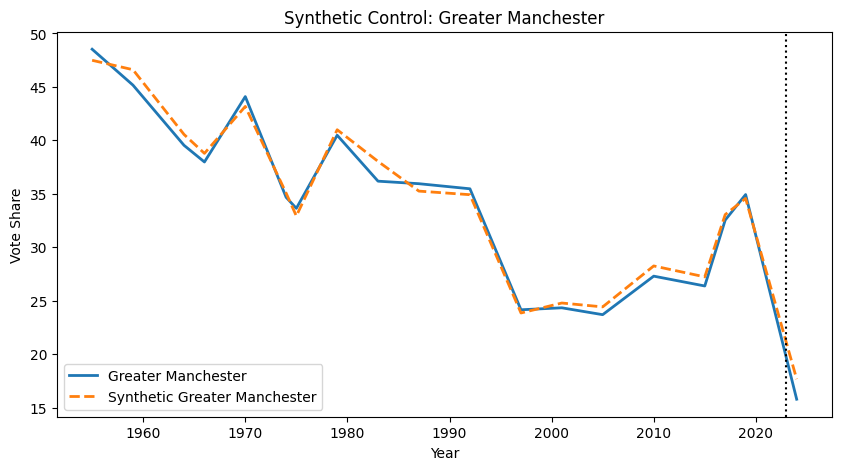

In [117]:


plt.figure(figsize=(10, 5))
plt.plot(Y_treated, label=TREATED_UNIT, linewidth=2)
plt.plot(Y_synthetic, label=f"Synthetic {TREATED_UNIT}", linestyle="--", linewidth=2)
plt.axvline(TREATMENT_YEAR, color="black", linestyle=":")
plt.legend()
plt.title(f"Synthetic Control: {TREATED_UNIT}")
plt.ylabel("Vote Share")
plt.xlabel("Year")
plt.show()

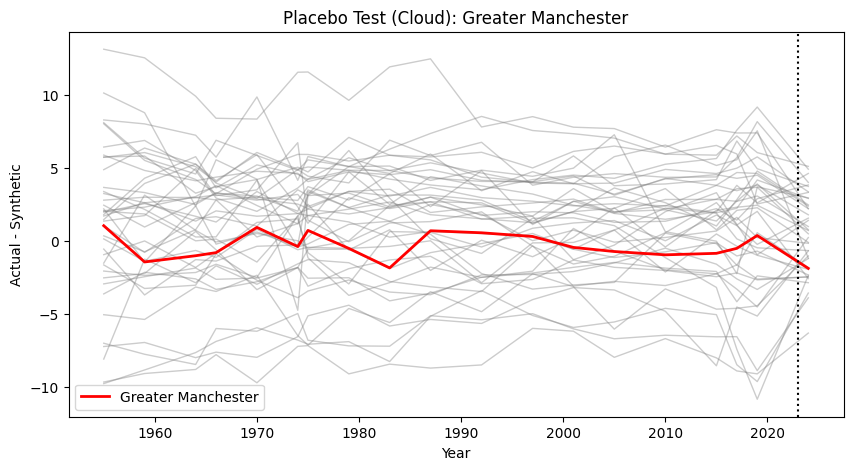

In [118]:


plt.figure(figsize=(10, 5))

# Grey cloud
for eff in placebo_effects.values():
    plt.plot(eff.index, eff.values, color="grey", alpha=0.4, linewidth=1)

# Treated effect
plt.plot(
    treatment_effect.index,
    treatment_effect.values,
    color="red",
    linewidth=2,
    label=TREATED_UNIT
)

plt.axvline(TREATMENT_YEAR, color="black", linestyle=":")
plt.legend()
plt.title(f"Placebo Test (Cloud): {TREATED_UNIT}")
plt.ylabel("Actual - Synthetic")
plt.xlabel("Year")
plt.show()

For Greater Manchester this is within the range of the cloud so there's no evidence of big difference